# Step 0: Hypothesising 

## Hypothesis: 
- There is some form of proportional relationship between KO and PEP stock prices that I can utilise for pairs trading. 

## Rationale behind hypothesis:
- KO and PEP sell similar products to similar consumers
- They face the same input costs (sugar, aluminium, logistics)
- They're valued by investors using similar multiples (P/E ratios etc.)
- Therefore if KO's price goes up by X%, PEP's price should go up by roughly some proportional amount

We may now work towards uncovering this relationship

# Step 1: Retrieving data

## Pull data from yfinance. 

### In **yf.download**, we accept the parameters: 
  1. tickers= → accepts a single string or a list of strings
  2. start= → string start date inclusive in the format YYYY-MM-DD
  3. end= → string end date inclusive in the formaat YYYY-MM-DD
  4. interval= → bar size, i.e. each row has what length of time worth of data. If interval="1h", each row has one hour of price data. We generally work with 1d
  5. auto_adjust=True(default) → for eg, if a company does a 2-for-1 stock split, it means every existing share doubles into 2 new ones. Stock price would be halved. If we have auto_adjust=False, it would look like the stock had a 50% crash. Autoadjust accounts for these fluctuations

  - yfinance also imports pandas internally, so the returned object from .download is actually a pandas dataframe, and we can use pandas methods on it

## Why use Close data?
We COULD use the other data (except Volume because it is not price related), but Close is standard because:
1. Represents the final agreed price of the day after all trading activity
2. It establishes the true benchmark for a stock's value until the next day

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

In [3]:
tickers = ["KO", "PEP"]
START, END = "2015-01-01", "2024-01-01"
df = yf.download(tickers, start=START, end=END) #returns a pandas dataframe object 
prices = df["Close"]


[*********************100%***********************]  2 of 2 completed


# Step 2: Data Cleaning

## A) Filling up NaN values with .ffill() and .dropna()
### .ffill()
- uses data from the previous day to fill up a NaN value. 
- If a stock didn't trade today, the last known price is the best estimate of the value, unless that last known price is from too long ago
- we can pass the parameter limit=. This sets a limit on the number of days to look back to since ffill by default looks back as far as possible to get the previous data
### .dropna()
- removes any NaN values


- here, we use .ffill() AND THEN .dropna(), but why not .dropna() first before .ffill()?
  1. By filling before dropping NaN values, we prevent rows where KO has a valid value but PEP does not from being removed, meaning less data is removed
  2. Initially, I wondered wouldn't it be better to NaN values dropped first, before we ffill since we can use a price from multiple days ago if the previous day's price is also NaN. However, this is unideal as a 2-day gap is generally suspicious enough that it is safer to remove the price than fabricate it

In [4]:
# forward filling and dropping NaN values
prices = prices.ffill()
prices = prices.dropna()

## B) Minimum History Requirement
- here for KO and PEP, we are running a ***cointegration statistical test***. 

### What is a Cointegration Statistical Test
- It is essentially testing "is the relationship between KO and PEP real or could it be random?"
- We need sufficient data to ensure the p-value our statistical test produces has enough statistical power, if not the the p-value would be inconclusive and it would be unwise to act on it since any relationship shown could be from chance without sufficient data points to prove it is not. 
- Generally there are 2 types of Cointegration tests, the Engle-Granger Test and the Johansen Test
  - To put it simply, the Engle-Granger Test is used for 2 variables, while the Johansen Test is used for analysis of multiple time series at the same time, i.e. more than two variables

### Why check for 2 years worth of trading data specifically?
- To cover a full market cycle with a reasonable chance to capture both bullish and bearish market conditions. A relationship that only holds in one regime is not useful
- We will be using the Engle-Granger Test which generally needs a few hundered observations to produce reliable p-values
- The relationship needs time to express itself. Pairs trading relies on the spread mean-reverting (returning to their long-term historical means over time). If I only have say 3 months of data, I might not have seen enough full cycles of the spread diverging and reverting to know its a real pattern
- Note the 2 years minimum is just the floor below which statistics become unreliable, we generally aim for at least 5 years worth of data

### In the code, why use the assert function?
- The program will terminate immediately when our quantity of data is insufficient, allowing us to adjust

In [5]:
# Minimum History Requirement check (I am doing a check for 5 years here to make my data more robust)
MIN_YEARS = 5
assert len(prices) >= 252 * MIN_YEARS, f"Need at least {MIN_YEARS} years of data"

#will produce 
# AssertionError: Need at least __ years of data
# if not enough data

## C) Synchronisation Test
- Here, we are checking that for each row, the trading dates for KO and PEP are the same
- This is important as further down, we are running code similar to what we have below:
```python
spread = prices["PEP"] - hedge_ratio * prices["KO"]
```
  - Pandas aligns by index automatically before doing the arithmetic. So if KO has a date that PEP doesn't, pandas would return NaN for that row rather than using the wrong price.
  - However, this means that misaligned dates would silently introduce NaNs into the spread, which would lead to issues downstream
- Generally, for large stocks in the same exchange, it is expected for the stocks to have the same date indices. However, this issue can be more prevalent in stocks traded in different exchanges, or for stocks which are smaller

### .index in a time series dataframe
- Usually, indices in a pandas dataframe are integers from 0 onwards, but when we load time series data like what we have here, the indices become dates in the form of YYYY-MM-DD, so we can naturally confirm the dates are the same by ensuring the indices are the same

### prices[ticker].index
- We are returning a Series (single column) of data from the ticker of our choice. In this case, the column we are returning is the column with the dates(indices)

In [6]:
#Synchronisation check
#Note .equals is a pandas function, but yfinance imports it internally and the Dataframe it returns is a panddas object
assert prices["KO"].index.equals(prices["PEP"].index), "Tickers have misaligned trading dates"

## D) Outlier Check
- Occassionally price data can contain anomalous spikes caused by a multitude of reasons, from data feed errors, to a flash crash that was later cancelled etc. These can look like a 20% move in a single day when nothing real happened
- We hence look at daily returns and flag anything which is statistically implausible

### Why are we checking if he deviation of returns from the mean is more than 5 x σ?
- In statistics:
  - ~68% of values fall between 1σ of the mean
  - ~95% within 2σ
  - ~99.7% within 3σ
  - ~99.99...% within 5σ
- This means a daily return that is 5σ away from the mean is super rare under normal conditions. It is either a data error or something major happened that day to cause such a legitimate major price change

### What is mask?
- A boolean DataFrame object with the same shape as returns and price, but every value is True/False. 
- we can do ```returns - mean ``` as the pandas DataFrame object is able to process it as each value in the table having the mean from its respective ticker subtracted from it
- A row with a True value is flagged as an outlier as it means the returns from that day exceeded 5σ and it is worth investigating
- We can then find the sum of the number of anomalous return values with the sum method acting on mask

In [7]:
# Outlier check
returns = prices.pct_change() #converting each data in the table to percentage change
mean = returns.mean() #returning a 1rx2c Series. Contains the means of KO and PEP from the percentage change data
std = returns.std() #returning a 1rx2c Series. Contains the standard deviations (σ) of KO and PEP from the percentage change data
mask = (returns - mean).abs() > 5 * std 
print(mask.sum())

Ticker
KO     12
PEP     8
dtype: int64


Interestingly, the program flagged 12 anomalous dates for KO and 8 for PEP, we shall investigate further:

Analysing each row data we have, we can notice that most of the data falls between 2019 to 2020. This is the peak period when the Covid-19 scare was first emerging. During this period, there is bound to be pessimistic trader sentiments, but also positive ones for when traders falsely assumed the economy may have gotten back on track quickly. However, if we analyse deeper, there are some anomalous dates worth investigating further:

- 14 February 2019 (KO)
  - This is way before the first case of Covid first emerged in Wuhan in around November 2019. This hence cannot be due to the Covid-19 pandemic and it is worth investingating
  - Researching deeper, we can find out that on this day at 6:55am EST, Coca-Cola reported its earnings and provided a pessimistic financial forecast for 2019, likely causing por trader sentiments as well, accounting for the anomalous fall in returns observed

- 23 July 2019 (KO)
  - Similarly, this is before any Covid-19 case first emerged
  - On this day, Coca Cola reported a highly successful Q2 2019 earnings, besting Wall Street consensus estimates, likely boosting trader sentiments which accounts for the anomalous increase in returns observed

- 18 May 2022 (KO & PEP)
  - This is towards the tail end of the Covid-19 pandemic, but it is strange that this is the only date in 2022, roughly a year and a half after the latest anomalous date raised before it
  - On this day, it can be seen that the U.S. stock market suffered its worst daily percentage drop since June 2020, driven by surging inflation and a looming recession. Many stocks were affected, not just KO and PEP

- For the remaining dates, they are all concentrated in 2020, with majority of the dates even being in March. It is safe to assume it is due to the early Covid-19 pandemic scares which led to poor trader sentiments. Any anomalous rise in returns could also be due to traders wrongly assuming the stock market would recover quickly, as mentioned earlier

For all the anomalous dates, it is still worth keeping them in our data set. This is because every single flagged date has a legitimate real-world explanation connected to genuine extreme market events.

Cases when it is indeed necessary to remove the data include:
- A stock showing a 50% drop and recovery within the same day (clearly erroneous)
- A price of $0 or negative appearing briefly
- A date showing a 30% move with absolutely no news or market context

In [8]:
ko_outliers = returns["KO"][mask["KO"]]
pep_outliers = returns["PEP"][mask["PEP"]]

print("KO outliers:")
print(ko_outliers)
print("\nPEP outliers:")
print(pep_outliers)

KO outliers:
Date
2019-02-14   -0.084355
2019-07-23    0.060719
2020-03-09   -0.061528
2020-03-12   -0.096725
2020-03-16   -0.066227
2020-03-19   -0.067336
2020-03-20   -0.084389
2020-03-26    0.064408
2020-04-06    0.064796
2020-06-11   -0.063348
2020-11-09    0.063094
2022-05-18   -0.069626
Name: KO, dtype: float64

PEP outliers:
Date
2020-03-12   -0.111060
2020-03-13    0.104994
2020-03-16   -0.112672
2020-03-17    0.129366
2020-03-20   -0.114283
2020-03-24    0.082335
2020-03-26    0.068978
2022-05-18   -0.061963
Name: PEP, dtype: float64


## E) Stationary Check

### Stationary vs Non-Stationary 
- Non-Stationary means a series has a **unit root** , meaning a value today is just yesterday's value plus some random noise, **with no pullback towards any mean**. The random fluctuation of the value is known as a **random walk**, where the series can drift anymore whith no tendency to revert. **Stock prices are meant to behave this way.**
- Stationary means a series has **no unit root, but rather a mean-rewverting pull**. This means the series is pull back towards the mean rather than drifting freely. **Stock returns are meant to behave this way**
- A stationary data series also has a constant mean, variance and autocorrelation structure over time.

### What is the ADF Test (Augmented Dickey-Fuller)?
- Tests whether a time series is stationary or non-stationary
- Null hypothesis is that the series has a unit root and is non-stationary, while the alternate hypothesis is that the series has no unit root and is stationary
- If p < 0.05, we have statistical evidence the series is stationary and we can reject the null hypothesis

### Aim of this check
- This check acts as a data sanity check to ensure the data we have actually behaves like a stock
- The fact is that stock price data is non-stationary, while their return data is stationary
- If our data does not behave as such, our data is arguably not stock data, indicating that there is something wrong

### Why is returns data stationary, but raw price data not?
- Raw prices drift because each day's price builds on the previous day's price, so the gains accumulate
- Returns don't accumulate that way and each day's return is relatively independent
- Over some years, there's no reason for the average daily return to systematically drift upward or downward. Stock price growth is always by a certain percentage and it just oscillates around some small positive mean (since stocks generally trend up slowly over time, the mean return is slightly above zero, but it's stable).

### What is the output of the adfuller method?
- A tuple with 6 elements:
  1) Test statistic → The more negative it is, the stronger the evidence against the null hypothesis. On its own it doesn't mean much, it needs to be interpreted relative to the critical values (element 5)
  2) p-value 
  3) Number of lags used → Chosen automatically, accounts for autocorrelation in the series
  4) Number of observations → number of data points used in the test after accounting for the lags
  5) Critical values (dictionary) → Thresholds for the test statistic at each significance level 1%, 5%, 10%. Our test statistic can be compared at each of these critical values and we can reject the null hypothesis at each significance level
  6) Information criterion

### Extension
- Time series data which is non-stationary by default, but becomes stationary after being differenced exactly one time is data which is **integrated of order 1**, denoted as *I(1)* 
- Differencing means subtrating the previous value from the current value
- A time series which is already stationary is I(0), meaning our returns data is I(0)


In [9]:
from statsmodels.tsa.stattools import adfuller

for ticker in ["KO", "PEP"]:
    result = adfuller(prices[ticker].pct_change().dropna())
    print(f"{ticker} ADF p-value: {result[1]:.4f}")

KO ADF p-value: 0.0000
PEP ADF p-value: 0.0000


# Step 3: Cointegration Test (Engle-Granger)

## What is it?
- Checks whether multiple non-stationary time series share a stable, long-run equilibirum relationship
- If cointegrated, while the stock prices may fluctuate and the difference in price between the 2 stocks can be stretched or narrowed temporarily, it will always come back to a stable long-term equilibrium distance from each other eventually.
- If not-cointegrated, the variables will drift apart indefinitely and the distance in prices between the 2 stocks can change indefinitely. Any relationship between them now is likely just a coincidence  
- If we have only 2 variables, we use a Engle-Granger test, while we generally use a Johansen test for more than 2 variables
- Relating back to our hypothesis, this test ensures that there is indeed a relationship between the two stocks before we go any further, preventing us from wasting our time later on if no such grounded relationship does exist in the first place

## Extension and note
- In this version, a Engle-Granger cointegration test is used followed by the OLS Regression (Linear Regression) in step 4 to find the hedge ratio (coefficient of KO in our proposed proportional relationship)
- However, a known limitation of the Engle-Granger test is that it is assymetrical
  - For context, the Engle-Granger algorithm here works by first running its own OLS Regression internally to get the residuals (vertical distance between an observed data point and a predicted value on the regression line), before running the ADF test (as seen in step 2E) on the residuals to test for stationairty
  - The assymetry arises from the internal OLS Regression done as regressing KO on PEP would produce different residuals compared to regressing PEP on KO. The ADF test on the residuals from KO on PEP regression would hence yield a different p-value compared to that of PEP on KO, making it assymetrical in that sense
- A work-around would be to use the Johansen test immediately instead
  - Johansen test does not use OLS Regression internally, but rather a mathematical approach called "eigenvalue decomposition of the covariance structure between the 2 series simultaneously", finding the linear combination that is most stationary without designating either variable as dependent or independent, making it symmetric by design.
  - With the Johansen test, we can skip the OLS regression that we would use in step 4, and instead use an output from the Johansen test called the "cointegrating vector", which is in fact the more stationary hedge ratio/coefficient that we want to get in step 4
  - I will adopt a Johansen test approach in later practice

## The coint method
- Accepts the following parameters:
  1) x1= → first price series (req)
  2) x2= → second time series (req)
  3) trend= → whether to incluyde a constant/trend in the test. Default value is "c", meaning we include a constant as the mean we are expecting is non-zero. If the input "ct", it means we expect a non-zero mean, but we expect the mean to change over time as well, so we include a constant and a time trend. If we input "nc", it means there is no constant and the spread mean is exactly zero, which is rare
  4) method= → which cointegration test to use. Default value is "aeg" which stands for the Engle-Granger test. If we want the Johansen test, we have to use a completely different method from the statsmodels library
  5) maxlag= → auto
  6) autolag → how to select the optimal lag count. Default value is "aic"

- Returns the a tuple of (test_score, p-value, critical_values) 

As seen below, we have a test score of -3.9133, a p-value of 0.0095 and critical values of -3.9012861 at the 1% level of significance, -3.33883133 at the 5% level of significance and -3.04632468 at the 10% level of significance.

We can hence reject the null hypothesis at the 1% level of significance as our test score value of -3.9133 is lower than the critical value of -3.9012861 at the 1% level of significance.

We can also reject the null hypothesis as the chance of the relationship between KO and PEP being due to chance is 0.95%, which is much lower than a critical value of p = 0.05. 

This makes sense as coke and pepsi are very similar products in the sense they are both cola soft drinks, so market volatility caused by consumer sentiments, supply chain issues or whatnot would affect them similarly.

In [10]:
from statsmodels.tsa.stattools import coint

score, pvalue, critical_values = coint(prices["KO"], prices["PEP"])
print(f"test score: {score:.4f}")
print(f"p-value: {pvalue:.4f}")
print(f"Critical values: {critical_values}")

test score: -3.9133
p-value: 0.0095
Critical values: [-3.9012861  -3.33883133 -3.04632468]


# Step 4: Estimating the Hedge Ratio (coefficient)

## Relating back to hypothesis
- Now that we have established that there is indeed a non-coincidental relationship between KO and PEP stock prices, we can work towards finding out the specific proportional relationship approach between KO and PEP stock prices that we want to adapt
- We may use a linear regression model, specifically a OLS regression algorithm to find out what is the coefficient (and constant) which enables there to be a relationship between KO and PEP stock prices
- In this case, for Y = mX + C, Y would be the stock price for PEP while X would be the stock price for KO. In finance terms, m which represents our coefficient, would thus be our hedge ratio, while C is still our constant 

## Using the OLS (Ordinary Least Sqaures) Regression - Linear Regression
- We will be running a OLS regression where we regress PEP (dependent variable Y) on KO (independent variable X)

### Why regress PEP on KO and not the other way round?
- By convention, the higher priced or higher volatility stock is the stock that we subtract from
- If we swap them, we will get a **different hedge ratio and a different spread**, which is a known limitation of using Engle-Granger in step 3 since at this point in time, we don't know which order would allow use to get a more stationary spread
- In practice:
  - Both spreads should be staionary regardless of the order if the pair is truly cointegrated
  - The spread values and hedge ratios will differ numerically
  - The trading signals generated will be slightly different
  - As a safeguard, it is good practice to:
  1) **Test both: run the regression both ways, check which residuals are more stationary using ADF (smaller p value), and use that one.**
  2) Use Johansen instead as it is symmetric by design

### Relating linear regression's Y = mX + c with the current hedge ratio approach
- In practice, the regression is not as simple as Y = mX + c as there is bound to some differences that we cannot explain. 
- We can rather follow a more complicated formula of ```PEP = hedge_ratio * KO + α + ε```
  - α is the **intercept term** and is a **constant**. It is estimated from the data representing the average level of the spread. This is our c in Y = mX + c
  - ε is the **error term** and is a **variable**, possessing a different value for every observation. It **represents the part of PEP's price that KO's price couldn't explain on that particular day**. This is the prior point raised on how some variations cannot always be explained and is thus not seen in the naive Y = mX + c model. 
  - Hence, in the context of ```PEP = α + hedge_ratio * KO + ε```, it means: "PEP's price equals a constant baseline, plus some multiple of KO's price, plus whatever is left over that we couldn't explain."
  - Therefore, we can **deduce ε is the spread** since on some days, ε can be lower/higher than the model predicts, which implies that ε determines the deviation from the long-run relationship on any given day
  - If the pair is truly cointegrated, then ε will oscillate around 0 and will not drift

## What are we doing in the code below?
### ```X = add_constant(prices["KO"])``` 
- For our dataframe with just the column of data for KO prices, we add a new colummn of just 1s:
  ```text
  Before add_constant:        After add_constant:
  X =                         X =
  KO                          const    KO   
  39.2                        1        39.2   
  38.8                        1        38.8
  39.1                        1        39.1
  ```
- This would enable the OLS algo to multiply this const column by an estimated coefficient α, and we hence get:
  ```text
  PEP = α * 1 + hedge_ratio * KO + ε
      = α + hedge_ratio * KO + ε
  ```
- This is necessary as in terms of statistical logic, very few relationships are perfectly directly proportional such that the linear regression line would cut through the origin. Without the constant, the OLS algorithmn would force the regression line through the origin, making the relationship become just ```PEP = hedge_ratio * KO```

### ```model = OLS(prices["PEP"], X) ```
- ```OLS(y_dataframe, x_dataaframe)``` → plot values from the y and x dataframes
- See this as the algorithmn setting up the graph of the data from the PEP dataframe against data from the KO dataframe with the constant column added (X), but not solving it yet

### ```model = model.fit()```
- Actually drawing the regression line through the graph, i.e. solving the problem

### ```model.params["KO"]```
- .params is a Series stored inside the results object, containing all the estimated coefficients
- Retrieve the coefficient value for KO that was estimated during the OLS
- We can also retrieve the value of the constant α that they deduced
- There are also other statistics we can retreive aside from .params such as .rsquared, .tvalues, .pvalues etc

## Extension
### How does OLS find multiple coefficients during the regression?
- From my understanding of linear regression, I had only done linear regression to determine the coefficient of 1 variable not multiple
- Linear regresion however, can handle many variables at once, with a general form of ```Y = β₀*x₀ + β₁*x₁ + β₂*x₂ + ... + ε```
- For the OLS algorithm, it solves the coefficients in one shot using matrix operation ```β = (XᵀX)⁻¹Xᵀy``` where X is the entire matrix of inputs (in our case the two columns "const" and "KO"), and β is a vector of all coefficients simultaneously

### Durbin-Watson
- Represents the autocorrelation in the residuals, meaning does today's residual (spread value) predict tomorrow's?
- Value ranges from 0 to 4:
  - ```~2``` → no autocorrelation (ideal for standard OLS assumptions)
  - ```<2``` → positive autocorrelation (today's residual predicts tomorrow's in the same direction)
  - ```>2``` → negative autocorrelation
- In our context, DW value is 0.028, meaning there is a strong positive autocorrelation between today's spread and tomorrow's
- This signals that spread will not suddenly snap back to the mean. The process is slow and gradual, giving us time to enter and exit positions profitably

In [11]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

X = add_constant(prices["KO"])
model = OLS(prices["PEP"], X)
model = model.fit()
print(model.summary())
hedge_ratio = model.params["KO"]
print(f"\nHedge ratio: {hedge_ratio:.4f}")

                            OLS Regression Results                            
Dep. Variable:                    PEP   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                 5.542e+04
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:18:46   Log-Likelihood:                -7332.9
No. Observations:                2264   AIC:                         1.467e+04
Df Residuals:                    2262   BIC:                         1.468e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -27.9155      0.591    -47.219      0.0

# What have we done so far?
0) Hypothesis: KO and PEP stock prices follow some form of proportional relationship that we may utilise for pairs trading
1) Data sourcing using 9 years of daily KO and PEP closing prices
2) Data cleaning by forward filling and dropping NaNs, minimum history checks, synchronisation checks, outlier checks and a data sanity check in the form of a stationary check on the return values of each stock, ensuring the data does indeed behave like stock data
3) Cointegration test to confirm that the prices for KO and PEP do indeed have a long-run equilibrium relationship that we can uncover
4) OLS Regression to begin actually trying to solve our hypothesis, seeing by what magnitude KO price has to change to somewhat match the price of PEP

# Step 5: Computing and Visualising the Spread

## What is a spread?
- A formulatic value that tracks the relative pricing relaitonship between two highly correlated assets
- Spreads can be defined in different ways via their formula, hence them being formula dependent
```text
spread
$20 |    *                        ← short the spread here
$15 |  *   *          *
$10 |--------*------*----*------  ← the mean ($10)
$5  |          *  *          *
$0  |                             ← long the spread here
     time →
```
- Let's say we have a formula of ```spread = PEP - hedge_ratio * KO``` and historically, the mean spread is $10, if the spread is greater than the mean, we can bet that the spread will eventually fall back to the mean, so we short the spread (sell PEP, buy KO). Likewise, if the spread is less than the historic mean, we long it (buy PEP, sell KO)

## What are the different spread approaches
### 1) Price-Neutral (ratio spread)
$spread = \frac{PEP}{KO}$
- Simplest out of the spread formulae and not generally used for actual trading
- Looks at the price ratio between the stocks → if PEP is historically 2x the price of KO, but it is suddenly 2.5x, we can short the spread (sell PEP, buy KO)

### 2) Dollar-Neutral 
```spread = PEP - hedge_ratio * KO```
- Scales positions of each stock so that the **total dollar value** of each leg is equal. 
- The most common formulation for pairs trading and the most intuitive to implement.
- The idea: a market-wide crash and many stock prices fall, it affects both legs equally in dollar terms, so they cancel out. P&L is purely from the relationship changing, 
  - eg if our current observed spread is lower than the historic mean, it means we are currently longing PEP and shorting KO. If we have a case where the stock price of PEP falls less than that of KO, then we still have a positive P&L → we correctly bet that **KO would fall more than PEP relative to their historical relationship to correct the spread to the historic mean spread. Market direction is irrelevant to the P&L**
- Can be used when betas are around the same

### 3) Beta-Neutral
```spread = PEP - (beta_PEP / beta_KO) * KO```
- Scales positions so that market exposure (beta) is equal across both legs, as beta can be different for different stocks
- The idea: dollar-neutral isn't always truly market-neutral. If PEP has a beta of 0.6 and KO has a beta of 0.8, a dollar-neutral position still has unequal market sensitivity — the KO leg moves more with the market per dollar. Beta-neutral corrects for this.
- Generally used for stocks which have more different betas, eg a tech stock with beta ~1.5 vs a utility stock with beta ~0.4

## What are we using here?
- Dollar-neutral spread as beta values for KO and PEP are very similar and it is the most intuitive to use for pairs trading

## What are we doing in the code below?
### ```spread = model.resid```
- As deduced from the previous step, ε is our spread
- Mathematically speaking, ε represents the vertical distance between the observed actual data point and the estimated data point on our regression line, linking back to the idea that ε represents the variations in value we cannot explain. It can be derived by: ```ε = PEP_actual - (α + hedge_ratio * KO_predicted)```, and is known as the **residuals**
- We can hence call ```model.resid``` to get a dataframe of all ε values 
- Alternatively, if we want to adopt a more mathematical approach, we can run:
```python
alpha = model.params["const"] #getting the constant from our OLS regression
spread = prices["PEP"] - alpha - hedge_ratio * prices["KO"] #mimicing the exact formula we used to derive ε
```

### ```spread.plot(title="KO/PEP Spread (Residuals)")```
- .plot() is a method from the pandas library which yfinance internally uses
- Any pandas Series or dataframe has a built-in .plot() method that internally calls matplotlib, so the ```dataframe.plot()``` capability is a pandas convenience method
- It is roughly equivalent to ```plt.plot(dataframe.index, dataframe.values)``` which is done using just matplotlib
- So we just run the pandas convenience code to set up the plot and then use the matplotlib methods directly

### ```plt.axhline(spread.mean(), color="red", linestyle="--", label="Mean")```
- Create a horizontal line on the axes, with the value being ```spread.mean()```
- color, linestyle and label are for the appearance of the line

## Analysis of the Graph
- spread oscillates around the mean (which is roughly 0 since we are using residuals as our spread), drifting away periodically but always eventually returning back to around the mean
- During the Covid-19 pandemic period from 2020 to 2021, there was a large deviation before reverting, which reflects how bearish market cycles can affect the trend, but ultimately the trend will still stand
- The graph hence also visually confirms the cointegration hypothesis

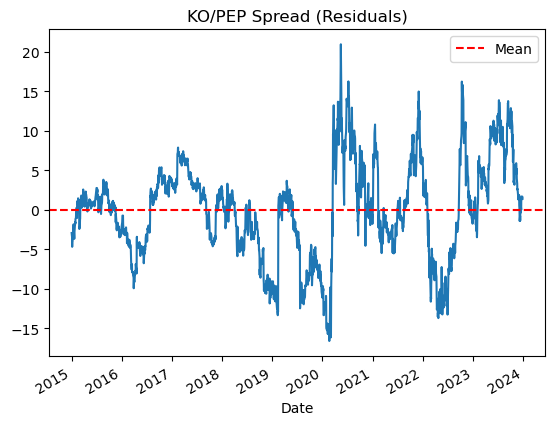

In [ ]:
import matplotlib.pyplot as plt

spread = model.resid #returns a Series

## OR
# alpha = model.params["const"]
# spread = prices["PEP"] - alpha - hedge_ratio * prices["KO"]

spread.plot(title="KO/PEP Spread (Residuals)")
plt.axhline(spread.mean(), color="red", linestyle="--", label="Mean")
plt.legend() #shows us the legends of the graph (the mean box in the top right showing what the red horizontal line means)
plt.show() #actually displays the graph

# Step 6: Z-Score and Signal Generation

## What is the Z-score?
- $z = \frac{x - \mu}{\sigma}$, where x is the raw data point
- Measures how many standard deviations a raw value is away from the mean

## Why use Z-score here instead of raw spread values?
- The z-score normalises the spread so that our entry/exit thresholds of ±2.0 are **universally meaningful** regardless of the spread's absolute value, allowing us to interpret the raw values easily

## Why are we calculating the mean z-score in intervals of 30 days?
- A larger window makes the z-score slower to react, incorporating more history so short-term deviations look less extreme, meaning fewer but potentially more reliable signals. 
  - eg, let's say for a theoretical spread and in a period of 100 days, we can see numerous times when raw spread changes by ±20.0, so our mean z-score value takes this into account and we know this is not something abnormal and is just a short-term expected deviation
- A smaller window makes it more reactive as deviations look more extreme relative to recent history, generating more signals but also more false positives. 
  - eg, for the same theoretical spread but in a period of 5 days, we see 4 days where raw spread is around ±5.0, but then one day when it jumps to +20.0. The mean z-score would incorportate how the raw spread had that seemingly abornmal surge and we would falsely deduce its a valid signal when in reality, when we look at 100 days, its something that happens decently often
- 30 days is a standard starting point balancing reactivity and stability.

## Why are we noting when the z-score goes beyond ±2.0?
- In statistics, recall 2 standard deviations captures ~95% of a normal distribution
- A z-score beyond ±2.0 means the spread is in the outer 5% of its recent historical range, making it unusual enough to bet on reversion without being too extreme 
- 2.0 is just the starting point, but in practice, quants tune this threshold during backtesting and some use values like 1.5 or 2.5

## What the zscore function is doing
### ```series.rolling(window)```
- Creates a rolling window object on your Series. 
- By itself it doesn't compute anything, we need to call another function on it to return a Series object with the same length as the original
- Note the first window-1 rows have NaN values as there are not sufficient dates for calculation to be done in adherence to the window

### ```series.rolling(window).mean()``` and ```series.rolling(window).std()```
- Using the rolling window object on our Series, compute a new mean z-score and z-score standard deviation **for each day** after day 30 inclusive  

### ```(series - mean_spread_window) / std_spread_window``` 
- Using the **raw spread value for each day** (represented by ```series```), **find the z-score for that day** using the **mean raw spread value** and the **mean raw spread standard deviation** from the **last 30 days (window) inclusive**

## Graph Analysis
- The z-score crosses both thresholds regularly, confirming the spread is genuinely mean-reverting and tradeable
- The crossings look fairly symmetric around zero (roughly as many long signals as short signals), which is what is expected from a mean-reverting spread

## Notes and Clarifications:
- Lookahead bias: when we use closing price data from a day **in the future** to calculate a signal for the current day, eg ```Day 1 close → somehow use Day 2's closing price to generate Day 1's signal```
- It is perfectly valid to use today's closing price data to generate a signal which can be used to trade when the market opens the next day
- Timeline is as such:
  ```text
  Market opens → prices move all day → market closes 
  → calculate spread using closing price 
  → calculate z-score 
  → signal generated
  → trade tomorrow's open
  ```
- Hence there is no lookahead bias at this step

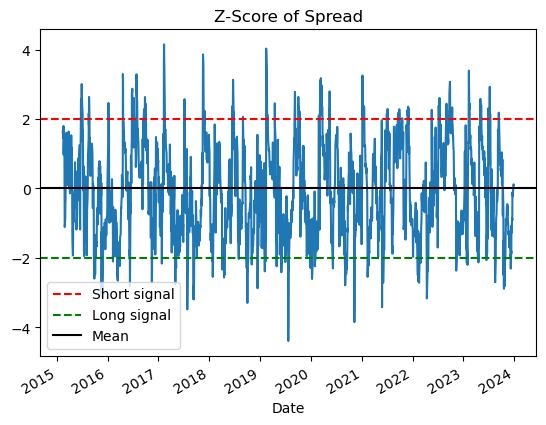

In [ ]:
def zscore(series, window=30):
    mean_spread_window = series.rolling(window).mean() # mean raw spread value of last 30 days, computed for each day
    std_spread_window = series.rolling(window).std() # std of the raw spread value of last 30 days, computed for each day
    return (series - mean_spread_window) / std_spread_window # return a series containing z-scores for the raw spread value of each day, using mean and std spread values from the last 30 days, starting from the current day 

z = zscore(spread) #calling the zscore function on the spread series, returning a series 
z.plot(title="Z-Score of Spread")
plt.axhline(2.0, color="red", linestyle="--", label="Short signal")
plt.axhline(-2.0, color="green", linestyle="--", label="Long signal")
plt.axhline(0, color="black", linestyle="-", label="Mean")
plt.legend()
plt.show()

# Step 7a: Backtesting using Cumulative Returns Chart
## Why are our entries ±2?
- As mentioned in the previous part, a z-score of 2 implies the raw spread value is 2 standard deviations away from the 30-day mean, inclusive of that day. 95% of data falls between 2 standard deviations of the mean, so being outside this range is anomalous enough to generate a signal

## What is being achieved in this code block?
- We aim to generate a dataframe which acts as our  **target positions**, which is our ```positions``` dataframe
- For each value in the table, it will give us our desired holding for that day, independent of whatever was done in the previous day in a non-accumulative manner (meaning each day, we are just declaring what our position should be, not adding on top of yesterday's)
- Later on, we will be basing trades based off the **difference between today's target and yesterday's target**, aa we need to execute a trade to reach said target:
  ```text
  Day 31: target = [1, -3.3157]   ← I want to hold 1 unit PEP
  Day 32: target = [1, -3.3157]   ← I still want to hold 1 unit PEP
  Day 33: target = [1, -3.3157]   ← still 1 unit PEP 
  Day 34: target = [0, 0]         ← exit signal, I want to hold nothing

  Day 31 → 32: difference = [0, 0] → no trade, just holding
  Day 33 → 34: difference = [-1, +3.3157] → close the position
  ```

## What are we doing in each line of code?
### ```pd.DataFrame(index=prices.index, columns=["PEP", "KO"]).fillna(0.0)```
- Generating a new dataframe where each row index is the prices index (dates of the trades), and the column headings are "PEP" and "KO"
- Initialising this table gives us a dataframe where each value is NaN
- We thus call .fillna(0,0) on the dataframe we initialised, meaning for column "PEP", set the value to 0 and for the column "KO", set the value to 0 too

### ```range(1, len(z))```
- In our for loop here, we use the ```iloc[]``` method instead of the ```loc[]``` method
  - ```iloc[]``` means we are indexing rows based on their integer index, not the date indices we gave them
  - Hence if we were to use ```loc[]```, we have to access each column by passing the exact date inside in the form of YYYY-MM-DD, which is not intuitive in this for loop logic
- We are going from index 1 to the last row in the z-score series, which has *len(z)* number of rows
- We start from 1 as in our else case, when our z-score for that day is neither anomalous or mean-reverting, we copy the previous day's position, meaning we do nothing. If we were to start from the day at index 0, there is no previous day to look back on which would produce a bug
  
### ```pd.isna(z.iloc[i]):```
- Using the pandas library's isna() method, we see if the value at index i in the z Series is a NaN value
- If so, we set our positions dataframe values at the same row index to be 0 for the PEP column and 0 for the KO column as well using ```positions.iloc[i] = [0, 0]```
- This is for the first 29 days of data which would not have a valid rolling window set up yet for the zscore to be calculated (see previous step for clarifications)

### ```positions.iloc[i] = [1, -hedge_ratio] or [-1, hedge_ratio] or [0, 0]```
- As mentioned earlier, we are not summing up the number of positions we aim to have at the end of each day, we just want to see what is our target positions for each day
- Also recall ```spread = PEP - hedge_ratio * KO```. Hence for our spread to be stationary / a constant value, for every 1 share of PEP longed/shorted, we need to short/long *hedge_ratio* shares of KO
- Declaring the row value at index i of the positions table to:
  - [1, -hedge_ratio] → signal is on; long 1 share of PEP, short hedge_ratio shares of KO  
  - [-1, hedge_ratio] → signal is on; short 1 share of PEP, long hedge_ratio shares of KO  
  - [0, 0] → signal is off; **close all positions**, hold no more shares or unclosed positiosn from shorting

### ```pnl = (positions.shift(1) * returns).sum(axis=1)```
- P&L calcualted here is in the form of percentage returns since our ```returns``` dataframe has ```.pct_changge()``` called on it
- As mentioned, we only enter a trade in the next day's market open, using signals and information up until the current day's market closing price
- This means that P&L for today would be based on the decision I made yesterday on what positions I want to hold today:
  ```text
  positions[t-1] = decision made at day t-1 close
  returns[t]     = price change from day t open to day t close
  pnl[t]         = positions[t-1] * returns[t]
  ``` 
- The dataframe returned from ```(positions.shift(1) * returns)``` still has 2 columns for KO and PEP's individual P&L from each day
- We then run ```.sum(axis=1)``` on it, meaning we sum across rows to return a Series with only one column. If we were to run ```.sum(axis=0)```, it is a sum across each column 

### ```cumulative = (1 + pnl).cumprod()```
- Compounded P&L returns in percentages, where the raw ```pnl``` values are in the form of percentages as decimal values, hence the need for the ```(1 + pnl)```
- Geometric compounding is done to correctly reflect compounded changes: ```$100 → +10% → $110 → -10% → $99```
- ```.cumprod()``` runs a cumulative product of numbers across a dataset, meaning for the value at index A, it uses the product of all numbers from index 0 to index A-1 and multiplies that by the number at index A in the orignal dataset:
  - Simple example: ```[2, 3, 4].cumprod() >> [2, 6, 24]```


## Graph Analysis
- From 2015-2019, the strategy loses money, dropping to ~0.65. This suggests the spread wasn't behaving as expected in this period. This could be due to the static hedge ratio not being well calibrated for early data
- From 2019-2020, there was a strong recovery up to ~1.3, then a massive drawdown to ~0.45 during Covid. This is the extreme z-score deviation we saw earlier (-5.0), where the spread blew out far beyond our entry threshold and kept going rather than reverting immediately, causing significant losses.
  - This is likely caused by ```PEP``` falling faster than ```hedge_ratio*KO```, so although the price of ```hedge_ratio*KO``` falling was helping minimise losses, it was not enough to offset the losses we were getting from longing PEP during this period
- From 2020-2023, there was strong recovery and it was the strategy's best period, peaking at ~1.95 (95% total return).
- From 2023-2024, the strategy gives back some gains, settling around 1.2-1.5.

## Limitations of using only the Cumulative Returns Chart for backtesting
- The graph onky provides a visual report of the strategy but we lack precise numbers to measure strategy performance against other strategies and benchmarks
- We hence combine this report with a Sharpe ratio and max drawdown calculation

C:\Users\User\AppData\Local\Temp\ipykernel_32500\3928137562.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions = pd.DataFrame(index=prices.index, columns=["PEP", "KO"]).fillna(0.0)


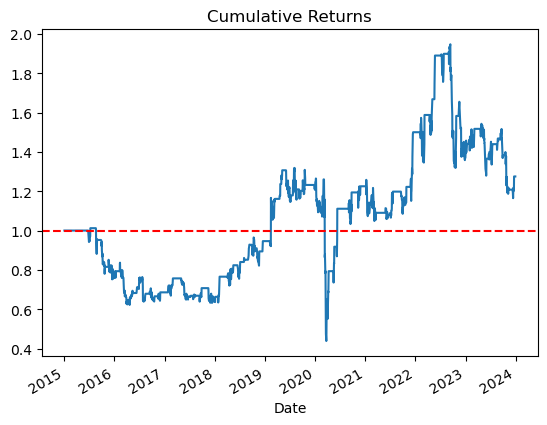

In [24]:
# Generate signals
long_entry  = z < -2.0 #generating a boolean Series based on whether each zscore value for that day fulfills the condition 
short_entry = z > 2.0
exit_signal = abs(z) < 0.5

# Build positions
positions = pd.DataFrame(index=prices.index, columns=["PEP", "KO"]).fillna(0.0)

for i in range(1, len(z)):
    if pd.isna(z.iloc[i]):
        positions.iloc[i] = [0, 0]
    elif long_entry.iloc[i]:
        positions.iloc[i] = [1, -hedge_ratio]
    elif short_entry.iloc[i]:
        positions.iloc[i] = [-1, hedge_ratio]
    elif exit_signal.iloc[i]:
        positions.iloc[i] = [0, 0]
    else:
        positions.iloc[i] = positions.iloc[i-1] #same position, just copy the previous day's action

# Calculate P&L
returns = prices.pct_change() #redeclared again for visual convenience
pnl = (positions.shift(1) * returns).sum(axis=1) #Individual P&L per day in the form of percentage returns
cumulative = (1 + pnl).cumprod() #Cumulative P&L overtime after each day of trading using compounding 

cumulative.plot(title="Cumulative Returns")
plt.axhline(1.0, color="red", linestyle="--")
plt.show()

# Limitations and Potential Improvements

## Different market regimes pre/post Covid which affects hedge ratio and market voltility
### Issue
- In step 5, we observed from our graph that before Covid, spread would generally be in a range between ±5 to ±10, whereas after Covid from 2019 onwards, spread increases and decreases more sporadically, with frequent spikes to values around ±15, signalling greater market volatility
- This is a phenomenon called **non-stationairty of variance** or **heteroskedasticity**, where the spread's volatility in 2020-2024 is structurally higher than 2015-2019
- From a mathematical/statistical standpoint, this shows that:
  - The standard deviation would be an average of the fluctuations in spread from 2015 to 2024. 
    - This is not the most accurate as this standard deviation value would be too high for usage from 2015 to 2019 and too low from 2019 onwards.
    - This would lead to our Z score in step 6 to be miscalibrated
    - This would also cause signals to be missed pre-Covid and too many false signals to be triggered post-Covid
  - The hedge ratio may have shifted
    - OLS regression estimated one static hedge ratio across the entire time frame I am working with
    - However, if the relationship between KO and PEP structurally changed post-Covid for whatever reason, that single static hedge ratio may no longer be accurate 
### Potential Improvement and how professionals address this
- Rolling hedge ratio
  - Instead of one static OLS regression over all 9 years, the hedge ratio is recalculated every N days using only a recent window
  ```python
  rolling_hedge = pd.Series(index=prices.index, dtype=float)
  for i in range(window, len(prices)):
    window_prices = prices.iloc[i-window:i]
    X = add_constant(window_prices["KO"])
    model = OLS(window_prices["PEP"], X).fit()
    rolling_hedge.iloc[i] = model.params["KO"]
  ```
  - This lets the hedge ratio adapt as the relationship evolves over time
- Regime detection
  - It is possible to model different market regimes and use different parameters for each
- Shorter lookback window
  - Using only recent data (say 2021-2024) for both the cointegration test and OLS means our hedge ratio and spread statistics reflect current market conditions rather than being diluted by an older regime.

# Big heading
## Smaller heading
### Even smaller

- item one
- item two
  - nested item (indent with 2 spaces)

1. first
2. second
3. third

**bold**
*italic*
`inline code`

$z = \frac{x - \mu}{\sigma}$

```python
x = 1 + 1
```